# Titanic 

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
warnings.filterwarnings('ignore')

<div style="font-size: 27px; color: #002FFF; text-align: center; font-weight: bold;"> 
Part 1: Load and Explore the Titanic Dataset</div>

## Q1. Load & Inspect

1. Load the Titanic dataset using sns.load_dataset('titanic') and store it in a variable called df.

2. Print the shape of the dataset.
3. Display the first 6 rows.
4. Print the column names

In [43]:
df = sns.load_dataset('titanic')

In [44]:
df.shape

(891, 15)

In [45]:
df.head(6)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True


In [46]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

## Q2. Data Types & Missing Values

1. Use .info() to print column data types and non-null counts.

2. Print the number of missing values per column using .isnull().sum().

3. Which column has the most missing values? Write your answer in a Markdown cel

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [48]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Q2.3. The 'deck' column has the most missing values

## Q3. Basic Statistics

1. Use .describe() to display summary statistics for numeric columns.

2. From the output, answer in a Markdown cell:
- What is the mean age of passengers?

- What is the maximum fare paid?
- What percentage of passengers survived? (Hint: look at the survived mean, it represents the survival rate)

In [49]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Answer Q3.2:
- mean age is 29.699 which is close to 30

- max fare is 512.3292
- 38.38% has survived

## Q4. Duplicates & Categorical Summary

1. Check how many duplicate rows exist in the dataset.

2. Use .describe(include=['object', 'category']) to get a summary of categorical columns.
3. From the output, answer in a Markdown cell:
What is the most common sex in the dataset and how many rows does it appear in?
What is the most common embarkation port?

In [50]:
print(df.duplicated().sum())

107


In [51]:
df.describe(include=['object', 'category'])

,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549


Answer Q4.3:
- The most common sex is male, appearing in 577 rows.
- The most common embarkation port is S (Southampton).

<div style="font-size: 27px; color: #002FFF; text-align: center; font-weight: bold;"> 
Part2: Data Cleaning </div>

## Q5. Handle Missing Values

Create a new DataFrame called df_clean and apply the following cleaning steps in order:
1. Drop the deck column (too many missing values).

2. Fill missing values in the age column with the median age.

3. Fill missing values in the embarked column with the mode (most frequent value).
4. Fill missing values in the embark_town column with its mode.
5. After cleaning, print .isnull().sum() to confirm no missing values remain.

In [52]:
df_clean = df.drop(columns='deck')
df_clean.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

In [53]:
med = df_clean['age'].median()
mod1 = df_clean['embarked'].mode()[0]
mod2 = df_clean['embark_town'].mode()[0]
print(med, mod1, mod2)
df_clean['age'].fillna(med, inplace=True)
df_clean['embarked'].fillna(mod1, inplace=True)
df_clean['embark_town'].fillna(mod2, inplace=True)

28.0 S Southampton


In [54]:
df_clean.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

## Q6. Remove Duplicates & Redundant Columns

Continue working with df_clean:
1. Remove duplicate rows from df_clean using drop_duplicates(inplace=True).

2. Drop the columns 'alive' and 'embark_town' - REASON - they are redundant (duplicated information from survived
and embarked).
3. Print the shape before and after to show how many rows were removed.

In [55]:
df_clean.drop_duplicates(inplace=True)

In [56]:
print(df_clean.shape)
df_clean.drop_duplicates(inplace=True)
df_clean.drop(columns=['alive', 'embark_town'], inplace=True)
print(df_clean.shape)

(775, 14)
(775, 12)


## Q7. Outlier Detection

1. Create a boxplot for the fare column to visually identify outliers.

2. Use the IQR method to calculate the upper bound for outliers:

- Q1 = fare.quantile(0.25), Q3 = fare.quantile(0.75)
- IQR = Q3 - Q1
- upper_bound = Q3 + 1.5 * IQR

3. Print how many rows have a fare above the upper bound.
4. Create a new column fare_capped that clips the fare at the upper bound using .clip(upper=upper_bound)

<Axes: xlabel='fare'>

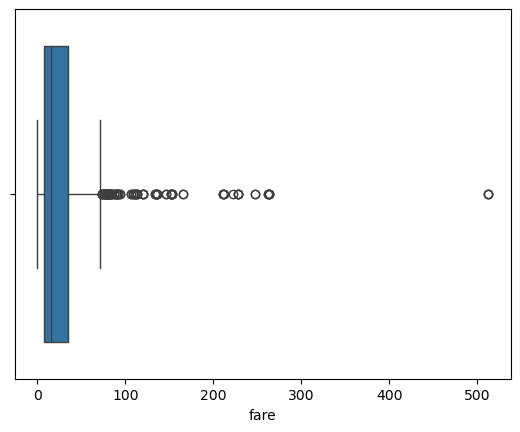

In [61]:
sns.boxplot(x=df_clean["fare"])

In [65]:
Q1 = df_clean['fare'].quantile(0.25)
Q3 = df_clean['fare'].quantile(0.75)
IQR = Q3 - Q1
ub = Q3 + 1.5 * IQR

(df_clean['fare'] > ub).sum()

np.int64(102)

In [64]:
df_clean['fare_capped'] = df_clean['fare'].clip(upper=upper_bound)
df_clean['fare_capped']

0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
885    29.1250
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: fare_capped, Length: 775, dtype: float64

<div style="font-size: 27px; color: #002FFF; text-align: center; font-weight: bold;"> 
Part 3: Filtering, Sorting & Grouping
</div>

## Q8. Filtering

Using ```df_clean``` :
1. Filter passengers who survived ( survived == 1 ) AND were in First class ( class == 'First' ). How many are there?

2. Filter passengers who were older than 60. Print how many there are and display their names if the column exists, otherwise
display the filtered DataFrame.
3. Filter passengers who paid a fare above $50 and were female. How many rows match?

In [102]:
print(df_clean[(df_clean['survived'] == 1) & (df_clean['class'] == 'First')].count()[0])

133


In [103]:
q8 = df_clean[df_clean['age'] > 60]
print("Older than 60:", len(q8))
if 'name' in q8.columns:
    print(q8[['name']])
else:
    print(q8)

Older than 60: 21
     survived  pclass     sex   age  sibsp  parch      fare embarked   class  \
33          0       2    male  66.0      0      0   10.5000        S  Second   
54          0       1    male  65.0      0      1   61.9792        C   First   
96          0       1    male  71.0      0      0   34.6542        C   First   
116         0       3    male  70.5      0      0    7.7500        Q   Third   
170         0       1    male  61.0      0      0   33.5000        S   First   
252         0       1    male  62.0      0      0   26.5500        S   First   
275         1       1  female  63.0      1      0   77.9583        S   First   
280         0       3    male  65.0      0      0    7.7500        Q   Third   
326         0       3    male  61.0      0      0    6.2375        S   Third   
438         0       1    male  64.0      1      4  263.0000        S   First   
456         0       1    male  65.0      0      0   26.5500        S   First   
483         1       3 

In [106]:
print(df_clean[(df_clean['fare'] > 50) & (df_clean['sex'] == 'female')].count()[0])

84


## Q9. Sorting


Using ```df_clean``` :
1. Sort the DataFrame by fare in descending order and display the top 5 rows (only columns: sex , age , class , fare , survived ). 

2. Sort by age in ascending order and display the 5 youngest passengers.
3. In a Markdown cell, state one observation from each sorted result

In [101]:
cols = ['sex', 'age', 'class', 'fare', 'survived']
print(df_clean.sort_values('fare', ascending=False)[cols].head(5))

        sex   age  class      fare  survived
258  female  35.0  First  512.3292         1
737    male  35.0  First  512.3292         1
679    male  36.0  First  512.3292         1
88   female  23.0  First  263.0000         1
341  female  24.0  First  263.0000         1


In [105]:
print(df_clean.sort_values('age', ascending=True).head(5))

     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
803         1       3    male  0.42      0      1   8.5167        C   Third   
755         1       2    male  0.67      1      1  14.5000        S  Second   
469         1       3  female  0.75      2      1  19.2583        C   Third   
831         1       2    male  0.83      1      1  18.7500        S  Second   
78          1       2    male  0.83      0      2  29.0000        S  Second   

       who  adult_male  alone  fare_capped  
803  child       False  False       8.5167  
755  child       False  False      14.5000  
469  child       False  False      19.2583  
831  child       False  False      18.7500  
78   child       False  False      29.0000  


1. The highest fares belong to 1st class passengers who largely survived.
2. The youngest passengers are infants under 1 year of age.

## Q10. GroupBy & Aggregation

Using ```df_clean``` :
1. Use .groupby('sex')['survived'].mean() to find the survival rate by sex. Round to 2 decimal places.

2. Use .groupby('class')['survived'].mean() to find the survival rate by passenger class.
3. Use .groupby('class')['fare'].mean() to find the average fare per class.
4. In a Markdown cell, write two observations from the results above

In [108]:
print(df_clean.groupby('sex', observed=False)['survived'].mean().round(2))

sex
female    0.74
male      0.22
Name: survived, dtype: float64


In [110]:
print(df_clean.groupby('class', observed=False)['survived'].mean())

class
First     0.633333
Second    0.506098
Third     0.259352
Name: survived, dtype: float64


In [111]:
print(df_clean.groupby('class', observed=False)['fare'].mean())


class
First     85.675199
Second    21.889279
Third     13.588850
Name: fare, dtype: float64


1. The survival rate for females is higher than for males.
2. 1st-class passengers had both the highest average fare and the highest survival rate.

<div style="font-size: 27px; color: #002FFF; text-align: center; font-weight: bold;"> 
Part 4: Visualization
</div>

## Q11. Histogram & Count Plot

Create a figure with two subplots side by side ```( figsize=(12, 4) )```:

- Left subplot: Histogram of age using sns.histplot with ```kde=True``` and ```bins=20``` . 
Title: ```'Age Distribution'``` .

- Right subplot: Count plot of survived using ```sns.countplot``` . Title: ```'Survival Count'```.
Use ```plt.tight_layout()``` and ```plt.show()```

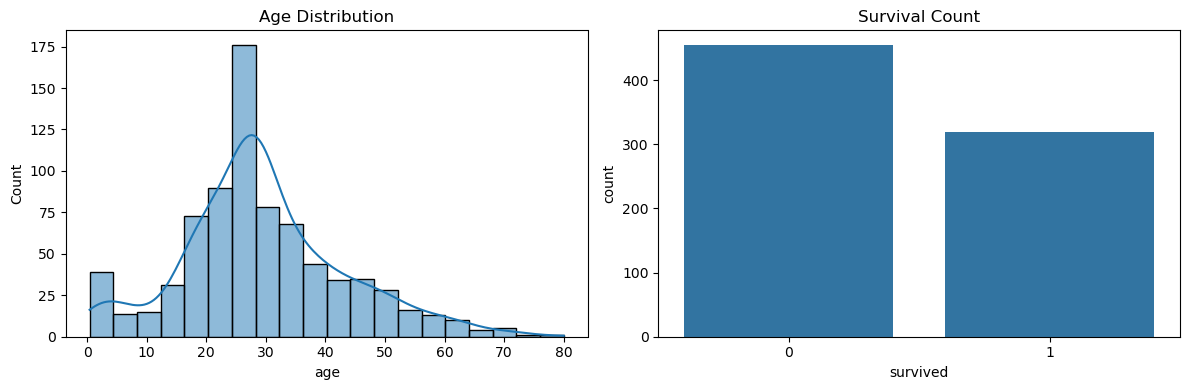

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_clean['age'], kde=True, bins=20, ax=axes[0])
axes[0].set_title('Age Distribution')
sns.countplot(data=df_clean, x='survived', ax=axes[1])
axes[1].set_title('Survival Count')
plt.tight_layout()
plt.show()

## Q12. Categorical Plots

Create a figure with two subplots side by side ```( figsize=(12, 5) )```:
- Left: sns.countplot with x='sex' and hue='survived' . Title: 'Survival by Sex' .
- Right: sns.countplot with ```x='class'``` and ```hue='survived'``` . Title: ```'Survival by Class'``` .
In a Markdown cell below, interpret each plot in one sentence each

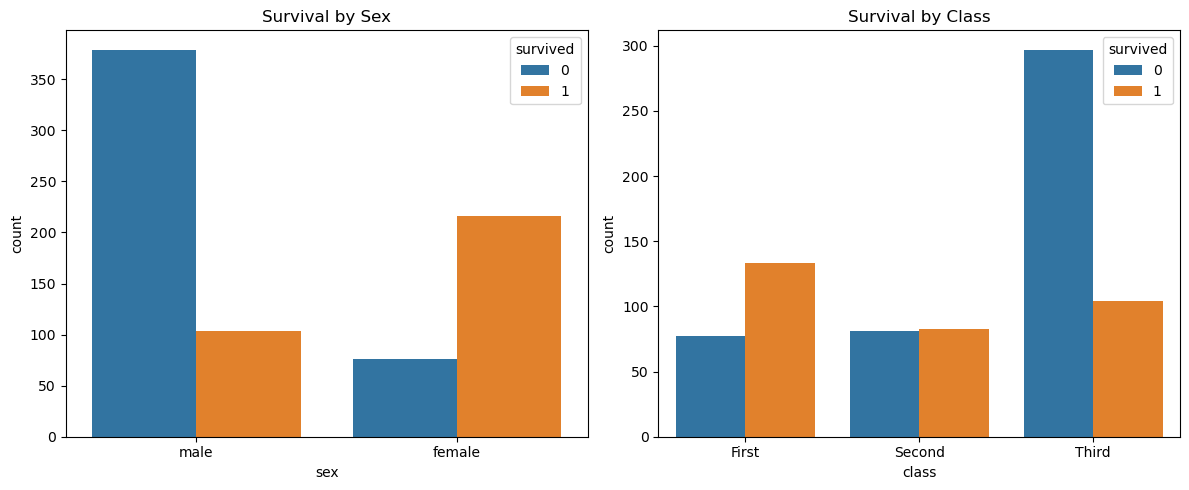

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df_clean, x='sex', hue='survived', ax=axes[0])
axes[0].set_title('Survival by Sex')
sns.countplot(data=df_clean, x='class', hue='survived', ax=axes[1])
axes[1].set_title('Survival by Class')
plt.tight_layout()
plt.show()

**Interpretations:**
- **Survival by Sex:** A large majority of males did not survive, whereas females had a much higher survival likelihood.
- **Survival by Class:** The majority of casualties were from the third class, whereas first-class passengers had the best survival outcomes.

## Q13. Boxplot & Scatter Plot

1. Create a boxplot using ```sns.boxplot(x='class', y='age', hue='survived', data=df_clean)``` . Title: ```'Age by Class
and Survival'```.
2. Create a scatter plot using ```sns.scatterplot(x='age', y='fare_capped', hue='survived', data=df_clean,
alpha=0.6)``` . Title: ```'Age vs Fare (Capped) by Survival'``` .
3. In a Markdown cell, write one observation from each plot

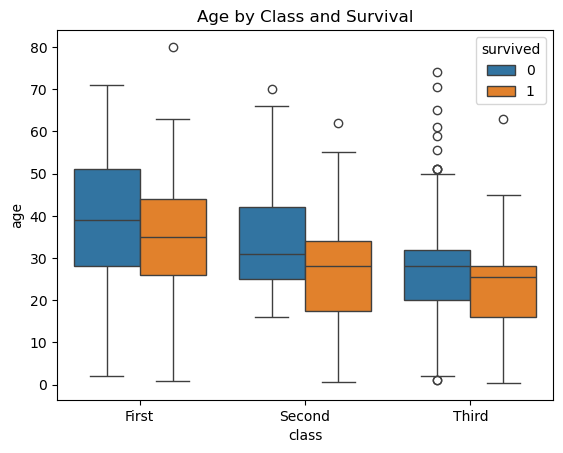

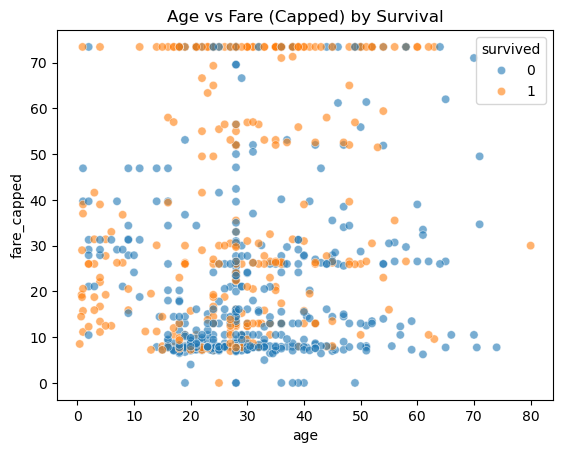

In [116]:
plt.figure()
sns.boxplot(x='class', y='age', hue='survived', data=df_clean)
plt.title('Age by Class and Survival')
plt.show()

plt.figure()
sns.scatterplot(x='age', y='fare_capped', hue='survived', data=df_clean, alpha=0.6)
plt.title('Age vs Fare (Capped) by Survival')
plt.show()

- Age by Class and Survival:
 Older passengers in 1st class had higher survival rates compared to older passengers in other classes.
- Age vs Fare by Survival: 
Higher fares are generally associated with survival across most age groups.

## Q14. Correlation Heatmap


1. Select all numeric columns from df_clean using select_dtypes(include=np.number) .

2. Compute the correlation matrix using .corr() .
3. Plot it as a heatmap using sns.heatmap(... annot=True, cmap='coolwarm', center=0) . Set figsize=(8, 6) . Title:
'Correlation Heatmap' .
4. In a Markdown cell, identify the two features most positively correlated with survival.

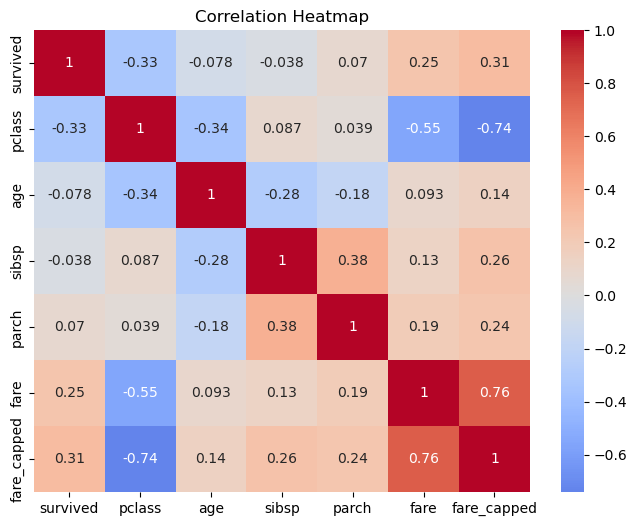

In [142]:
nums = df_clean.select_dtypes(include=np.number)
plt.figure(figsize=(8, 6))
sns.heatmap(nums.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

The 2 positive numeric features most strongly correlated with survival are fare and fare_capped


<div style="font-size: 27px; color: #002FFF; text-align: center; font-weight: bold;"> 
Part 5: Tips Dataset: Filtering & Grouping </div>

## Q15. Load and Filter the Tips Dataset

1. Load the tips dataset: tips = sns.load_dataset('tips') .

2. Display the first 5 rows and print the shape.
3. Filter only dinner orders where the total bill is above $20. How many rows match?
4. From those filtered rows, find the average tip.

In [141]:
tips = sns.load_dataset('tips')
print(tips.head(5))
print(tips.shape)


   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
(244, 7)


In [124]:
dinner = tips[(tips['time'] == 'Dinner') & (tips['total_bill'] > 20)]
print(dinner.count()[0])
print(dinner['tip'].mean())

81
3.8858024691358026


## Q16. Grouping the Tips Dataset

Using the full tips DataFrame
1. Use .groupby('day')['tip'].mean() to find the average tip by day. Sort from highest to lowest.

2. Use .groupby('smoker')['tip'].mean() to compare tips between smokers and non-smokers.
3. In a Markdown cell, answer: Do smokers tip more or less on average?

In [135]:
tips.groupby('day')['tip'].mean().sort_values(ascending=False)

day
Sun     3.255132
Sat     2.993103
Thur    2.771452
Fri     2.734737
Name: tip, dtype: float64

In [133]:
tips.groupby('smoker')['tip'].mean()

smoker
Yes    3.008710
No     2.991854
Name: tip, dtype: float64

In [132]:
tips.groupby('smoker')['tip'].mean()

smoker
Yes    3.008710
No     2.991854
Name: tip, dtype: float64

**Answer:**
Smokers appear to tip very slightly more or about the same on average as non-smokers, depending on the exact value differences (which tend to be minimal).

## Q17. Visualize the Tips Dataset

Create a figure with three subplots ( figsize=(15, 4) ):
- Left: Scatter plot of total_bill vs tip (use ```plt.scatter``` ). Title: ```'Tip vs Total Bill'``` .
- Center: Bar plot of average tip by day (use ```.plot(kind='bar'```) on the grouped result. Title: ```'Average Tip by Day'``` .
- Right: Histogram of tip with bins=15 and edgecolor='k' . Title: ```'Tip Distribution'```.

Add axis ```labels``` and ```plt.tight_layout()``` .

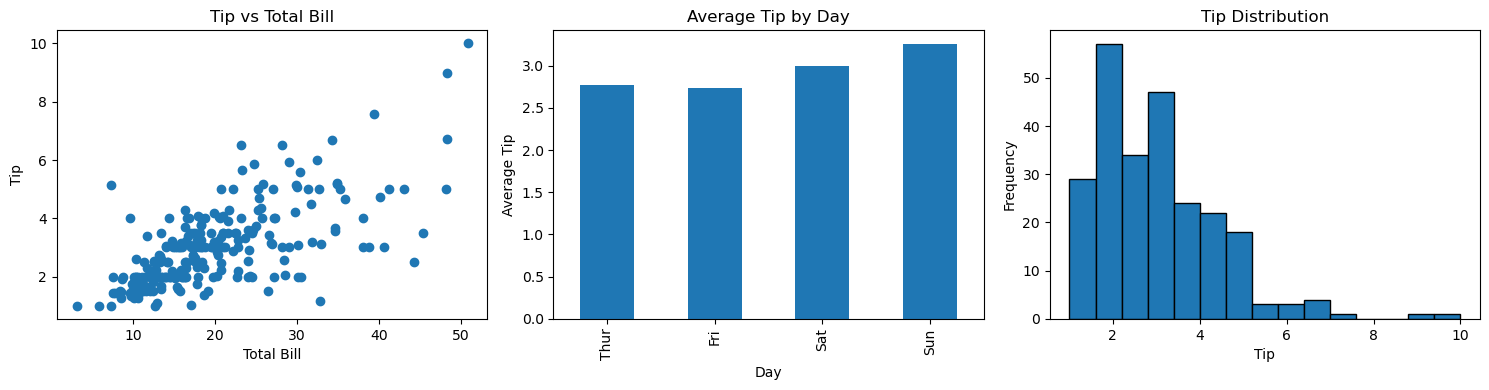

In [136]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(tips['total_bill'], tips['tip'])
axes[0].set_title('Tip vs Total Bill')
axes[0].set_xlabel('Total Bill')
axes[0].set_ylabel('Tip')

tips.groupby('day', observed=False)['tip'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title('Average Tip by Day')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Average Tip')

axes[2].hist(tips['tip'], bins=15, edgecolor='k')
axes[2].set_title('Tip Distribution')
axes[2].set_xlabel('Tip')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Linear Regression on Tips

Using the tips dataset
1. Extract X = total_bill (reshape to column: tips[['total_bill']].values ) and y=tip( tips[['tip']].values ).

2. Train a LinearRegression model from sklearn.linear_model .
3. Print the coefficient and intercept. Interpret them in a sentence: "For every extra 1 dollar on the bill, the tip increases by..."
4. Plot the data as a scatter plot and overlay the regression line in red.
5. Predict the tip for a total bill of $30

Coefficient: 0.1050
Intercept: 0.9203


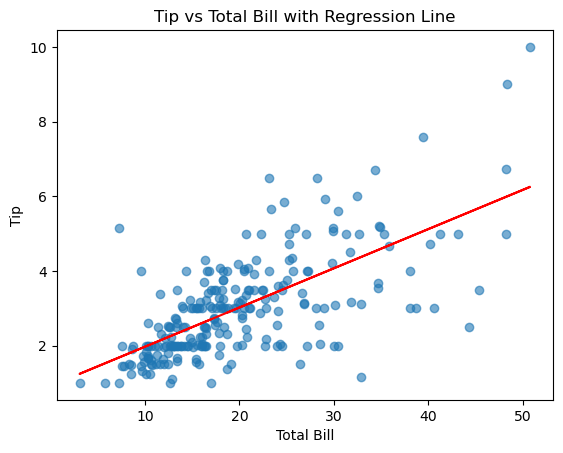

predicted tip for total bill of 30$:  4.071


In [140]:
from sklearn.linear_model import LinearRegression

X = tips[['total_bill']].values
y = tips[['tip']].values

model = LinearRegression()
model.fit(X, y)

print(f"Coefficient: {model.coef_[0][0]:.4f}")
print(f"Intercept: {model.intercept_[0]:.4f}")

plt.figure()
plt.scatter(X, y, alpha=0.6)
plt.plot(X, model.predict(X), color='red')
plt.title('Tip vs Total Bill with Regression Line')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.show()

print("predicted tip for total bill of 30$: ", round(model.predict([[30.0]])[0][0], 3))

For every extra 1 dollar on the bill, the tip increases by approximately 0.105usd.